In [6]:
#imports and libraries
!py -m pip install seaborn
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
train=pd.read_csv("../data/processed/train.csv")
val=pd.read_csv("../data/processed/val.csv")
test=pd.read_csv("../data/processed/test.csv")

xtrainScaled_smote=np.load("../data/processed/xtrain_scaled.npy")
ytrainSeverity_smote=np.load("../data/processed/ytrain_severity.npy")

FEATURES = [

    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
TARGET = "cases"

xtrainScaled=train[FEATURES]
xvalScaled=val[FEATURES]
xtestScaled=test[FEATURES]
ytrain=train[TARGET]
yval=val[TARGET]
ytest=test[TARGET]

In [8]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xtest,ytest):

    predictions=model.predict(xtest)
    meanSquareError=mean_squared_error(ytest, predictions)
    r2=r2_score(ytest, predictions)
    rootMeanSquareError=root_mean_squared_error(ytest, predictions)
    meanAbsoluteError=mean_absolute_error(ytest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [16]:
#Linear Regression as baseline model

linearRegression=LinearRegression()

linearRegression.fit(xtrainScaled,ytrain)

linearEvaluations=regressorEvaluation(linearRegression,xvalScaled,yval)

timecv=TimeSeriesSplit(n_splits=5)
cvScore=cross_val_score(linearRegression,xtrainScaled,ytrain,cv=timecv,scoring='r2')

print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")
jl.dump( linearRegression,"../models/linear_baseline.pkl")

The Model Performance metrics are:
R2 Score: 0.6354558253982945
Mean Squared Error: 403.1176182018696
Root Mean Squared Error: 20.077789176148592
Mean Absolute Error: 8.654252103386805
Cross Validation Average R2 Score: 0.6646
Cross Validation R2 Scores Std: 0.0619
Mean: 0.6646 ± 0.0619


['../models/linear_baseline.pkl']

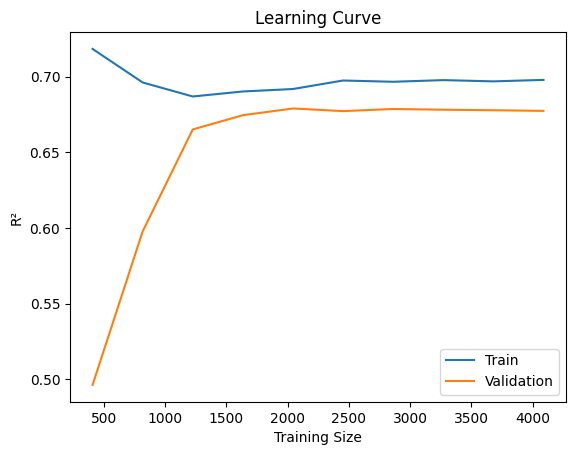

In [17]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    linearRegression, xtrainScaled, ytrain, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1),   label='Validation')
plt.xlabel('Training Size')
plt.ylabel('R²')
plt.legend()
plt.title('Learning Curve')
plt.show()

In [ ]:
#randomforest regressor
from sklearn.model_selection import TimeSeriesSplit,GridSearchCV

FEATURES_RF = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
TARGET_RF = "cases"

xtrainScaled_rf=train[FEATURES_RF]
xvalScaled_rf=val[FEATURES_RF]
xtestScaled_rf=test[FEATURES_RF]
ytrain_rf=train[TARGET_RF]
yval_rf=val[TARGET_RF]
ytest_rf=test[TARGET_RF]

gridparameters={
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 8]
}

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
    )


tcsv=TimeSeriesSplit(n_splits=5)

gridSearch=GridSearchCV(
    estimator=model,
    param_grid=gridparameters,
    cv=tcsv,
    scoring='r2',
    n_jobs=-1
)

gridSearch.fit(xtrainScaled_rf, ytrain_rf)

model=gridSearch.best_estimator_
evaluation=regressorEvaluation(model, xvalScaled_rf, yval_rf)
importance = model.feature_importances_

scores = cross_val_score(model, xtrainScaled_rf, ytrain_rf, cv=tcsv, scoring='r2')

print(f"CV R² scores: {scores.mean():.4f}")
print(f"Mean: {scores.mean():.4f} ± {scores.std():.4f}")


The Model Performance metrics are:
R2 Score: 0.21140178102753726
Mean Squared Error: 872.0420127347948
Root Mean Squared Error: 29.530357477260495
Mean Absolute Error: 10.716866173941128
CV R² scores: 0.7114
Mean: 0.7114 ± 0.2314


In [15]:
from xgboost import XGBRegressor as xgBoostRegressor


FEATURES_xg = [

    "district_encoded","T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "water_proxy",
    "month_sin", "month_cos",
    "week_sin", "week_cos","isOutbreak"
]
TARGET_xg = "cases"

xtrainScaled_xg=train[FEATURES_xg]
xvalScaled_xg=val[FEATURES_xg]
xtestScaled_xg=test[FEATURES_xg]
ytrain_xg=train[TARGET_xg]
yval_xg=val[TARGET_xg]
ytest_xg=test[TARGET_xg]

xgmodel = xgBoostRegressor(
    learning_rate=0.01,    # slower learning
    n_estimators=1000,     # more trees to compensate
    max_depth=3,           # keep shallow
    subsample=0.8,         # add some randomness
    colsample_bytree=0.8,  # add some randomness
    min_child_weight=5,    # prevents overfitting on small groups
    random_state=42,
    n_jobs=-1
)

xgmodel.fit(xtrainScaled_xg, ytrain_xg)
xgEvaluation=regressorEvaluation(xgmodel, xvalScaled_xg, yval_xg)
xgScores = cross_val_score(xgmodel, xtrainScaled_xg, ytrain_xg, cv=tcsv, scoring='r2')
print(f"XGBoost CV R² scores: {xgScores.mean():.4f}")
print(f"Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")


The Model Performance metrics are:
R2 Score: 0.263599693775177
Mean Squared Error: 814.3208618164062
Root Mean Squared Error: 28.53630828857422
Mean Absolute Error: 10.684389114379883
XGBoost CV R² scores: 0.7397
Mean: 0.7397 ± 0.2069
